# JavaScript Data Overview in Measurement Overview

In [1]:
import os
import pandas as pd
import re
from glob import glob
from tqdm import tqdm

# Define data path
DATA_PATH = os.path.join(os.getcwd(), '..', '..', '..', '02_Data', 'js_hashes')

# Get all matching CSV files
FILES = glob(os.path.join(DATA_PATH, 'all_hashes - *.csv'))

# Initialize empty DataFrame
DATA = pd.DataFrame()

# Function to extract the profile from the filename
def extract_profile(file):
    match = re.search(r'\b(EU|US)[12]\b', file)
    return match.group() if match else None

# Read and combine data
for file in tqdm(FILES, total=len(FILES), desc='Reading data'):
    d = pd.read_csv(file)
    d['profile'] = extract_profile(file)  # assign profile from filename
    DATA = pd.concat([DATA, d], ignore_index=True)

# Show result
DATA.head()

Reading data: 100%|██████████| 4/4 [00:04<00:00,  1.25s/it]


,content_hash,simhash_hex,profile
0,0b1aa66150c28868815c1cec85acff815804ff02590219...,ed120ca718cddd03,EU1
1,57a7a61dbb15837f05681727db456623b86081442341b4...,e3522cb4d94ed503,EU1
2,1b2df4a40d62140a3196727d9ced706998a4a37ee944c5...,c465bf674ecf2973,EU1
3,133205df77e5b7dac35dd3e55eeb3c7bf8ffdb064a7f7c...,e9522db49aced599,EU1
4,0d0d03bad902ea517c6cbc35459815a974c7d296e5f378...,c93609b6104ff749,EU1


In [11]:
print(f"[Measurement.Overview.JavaScript.1.0] Number of JS files: {len(DATA)} ")

[Measurement.Overview.JavaScript.1.0] Number of JS files: 6280920 


In [4]:
import numpy as np
eu1 = DATA[DATA['profile'] == 'EU1']
eu2 = DATA[DATA['profile'] == 'EU2']
us1 = DATA[DATA['profile'] == 'US1']
us2 = DATA[DATA['profile'] == 'US2']

base = [len(eu1), len(eu2), len(us1), len(us2)]

print(f"[Measurement.Overview.JavaScript.1.1] Number of JS Files: mean: {np.mean(base)}, min: {np.min(base)}, max: {np.max(base)}, SD: {np.std(base)}")

[Measurement.Overview.JavaScript.1.1] Number of JS Files: mean: 1570230.0, min: 1277279, max: 1877173, SD: 292620.95368069597


In [17]:
print(f"Number of files per profile: EU1: {len(eu1)}, EU2: {len(eu2)}, US1: {len(us1)}, US2: {len(us2)}")

Number of files per profile: EU1: 1877173, EU2: 1848169, US1: 1277279, US2: 1278299


In [13]:
distinct_simhashes = list(set(DATA['simhash_hex'].tolist()))
print(f"[Measurement.Overview.JavaScript.1.2] Number of distinct JS files: {len(distinct_simhashes)} ")

[Measurement.Overview.JavaScript.1.2] Number of distinct JS files: 902628 


In [15]:
distinct_simhashes_eu1 = list(set(eu1['simhash_hex'].tolist()))
distinct_simhashes_eu2 = list(set(eu2['simhash_hex'].tolist()))
distinct_simhashes_us1 = list(set(us1['simhash_hex'].tolist()))
distinct_simhashes_us2 = list(set(us2['simhash_hex'].tolist()))

base = [len(distinct_simhashes_eu1), len(distinct_simhashes_eu2), len(distinct_simhashes_us1), len(distinct_simhashes_us2)]

print(f"[Measurement.Overview.JavaScript.1.3] Number of distinct JS files per profile: mean: {np.mean(base)}, min: {np.min(base)}, max: {np.max(base)}, SD: {np.std(base)}")

[Measurement.Overview.JavaScript.1.3] Number of distinct JS files per profile: mean: 513579.5, min: 454750, max: 574498, SD: 58614.84162522321


## EU1
[Measurement.Overview.JavaScript.2.0] Size of JavaScript files - mean: 40416.80208709298, min: 21, max: 20407229, SD: 111486.94092289885
[Measurement.Overview.JavaScript.2.1] Total size: 75922881887
[Measurement.Overview.JavaScript.2.2] Sites without JS : 7908

## EU2
[Measurement.Overview.JavaScript.2.0] Size of JavaScript files - mean: 40338.088040248826, min: 21, max: 20407229, SD: 111121.92033423098
[Measurement.Overview.JavaScript.2.1] Total size: 74605092140
[Measurement.Overview.JavaScript.2.2] Sites without JS : 7918


## US1

## US2
[Measurement.Overview.JavaScript.2.0] Size of JavaScript files - mean: 44106.17798226797, min: 0, max: 20407229, SD: 123281.76001852335
[Measurement.Overview.JavaScript.2.1] Total size: 56438485877
[Measurement.Overview.JavaScript.2.2] Sites without JS : 8100



In [ ]:
js_eu1 = {'min':21, 'max':20407229, 'mean':40416, 'std':111486}
js_eu2 = {'min':21, 'max':20407229, 'mean':40338, 'std':111121}
js_us1 = {'min':, 'max':, 'mean':, 'std':}
js_us2 = {'min':0, 'max':20407229, 'mean':44106, 'std':123281}

_min = [js_eu1['min'], js_eu2['min'], js_us1['min'], js_us2['min']]
_max = [js_eu1['max'], js_eu2['max'], js_us1['max'], js_us2['max']]
_mean = [js_eu1['mean'], js_eu2['mean'], js_us1['mean'], js_us2['mean']]
_std = [js_eu1['std'], js_eu2['std'], js_us1['std'], js_us2['std']]

print(f"[Measurement.Overview.JavaScript.2.0] Size in bytes for JavaScript: mean: {np.mean(_mean)}, min: {np.mean(_min)}, max: {np.mean(_max)}, SD: {np.mean(_std)}")

In [3]:
distinct_simhashes = list(set(DATA['simhash_hex'].tolist()))
print(f"[Measurement.Overview.JavaScript.3.0] Distinct JavaScripts based on SimHash: {len(distinct_simhashes)}")

[Measurement.Overview.JavaScript.3.0] Distinct JavaScripts based on SimHash: 902628


In [14]:
print("[Measurement.Overview.JavaScript.3.1]")

set_simhashes_eu1 = set(eu1['simhash_hex'].tolist())
set_simhashes_eu2 = set(eu2['simhash_hex'].tolist())
set_simhashes_us1 = set(us1['simhash_hex'].tolist())
set_simhashes_us2 = set(us2['simhash_hex'].tolist())

def compute_intersection(input1, input2):
    return input1.intersection(input2)

def compute_difference(input1, input2):
    return input1.difference(input2)

int_eu1_eu2 = compute_intersection(set_simhashes_eu1, set_simhashes_eu2)
diff_eu1_eu2 = compute_difference(set_simhashes_eu1, set_simhashes_eu2)
diff_eu2_eu1 = compute_difference(set_simhashes_eu2, set_simhashes_eu1)
print(f"Intersection between EU1 and EU2 {len(int_eu1_eu2)}")
print(f"Difference between EU1 and EU2 {len(diff_eu1_eu2)}")
print(f"Difference between EU2 and EU1 {len(diff_eu2_eu1)}")
print("")

int_us1_us2 = compute_intersection(set_simhashes_us1, set_simhashes_us2)
diff_us1_us2 = compute_difference(set_simhashes_us1, set_simhashes_us2)
diff_us2_us1 = compute_difference(set_simhashes_us2, set_simhashes_us1)
print(f"Intersection between US1 and US2 {len(int_us1_us2)}")
print(f"Difference between US1 and US2 {len(diff_us1_us2)}")
print(f"Difference between US2 and US1 {len(diff_us2_us1)}")
print("")

int_eu1_us1 = compute_intersection(set_simhashes_eu1, set_simhashes_us1)
diff_eu1_us1 = compute_difference(set_simhashes_eu1, set_simhashes_us1)
diff_us1_eu1 = compute_difference(set_simhashes_us1, set_simhashes_eu1)
print(f"Intersection between EU1 and US1 {len(int_eu1_us1)}")
print(f"Difference between EU1 and US1 {len(diff_eu1_us1)}")
print(f"Difference between US1 and EU1 {len(diff_us1_eu1)}")
print("")

int_eu1_us2 = compute_intersection(set_simhashes_eu1, set_simhashes_us2)
diff_eu1_us2 = compute_difference(set_simhashes_eu1, set_simhashes_us2)
diff_us2_eu1 = compute_difference(set_simhashes_us2, set_simhashes_eu1)
print(f"Intersection between EU1 and US2 {len(int_eu1_us2)}")
print(f"Difference between EU1 and US2 {len(diff_eu1_us2)}")
print(f"Difference between US2 and EU1 {len(diff_us2_eu1)}")
print("")

int_eu2_us1 = compute_intersection(set_simhashes_eu2, set_simhashes_us1)
diff_eu2_us1 = compute_difference(set_simhashes_eu2, set_simhashes_us1)
diff_us1_eu2 = compute_difference(set_simhashes_us1, set_simhashes_eu2)
print(f"Intersection between EU2 and US1 {len(int_eu2_us1)}")
print(f"Difference between EU2 and US1 {len(diff_eu2_us1)}")
print(f"Difference between US1 and EU2 {len(diff_us1_eu2)}")
print("")

int_eu2_us2 = compute_intersection(set_simhashes_eu2, set_simhashes_us2)
diff_eu2_us2 = compute_difference(set_simhashes_eu2, set_simhashes_us2)
diff_us2_eu2 = compute_difference(set_simhashes_us2, set_simhashes_eu2)
print(f"Intersection between EU2 and US2 {len(int_eu2_us2)}")
print(f"Difference between EU2 and US2 {len(diff_eu2_us2)}")
print(f"Difference between US2 and EU2 {len(diff_us2_eu2)}")


Intersection between EU1 and EU2 398652
Difference between EU1 and EU2 171192
Difference between EU2 and EU1 175846

Intersection between US1 and US2 374771
Difference between US1 and US2 80455
Difference between US2 and US1 79979

Intersection between EU1 and US1 356201
Difference between EU1 and US1 213643
Difference between US1 and EU1 99025

Intersection between EU1 and US2 355402
Difference between EU1 and US2 214442
Difference between US2 and EU1 99348

Intersection between EU2 and US1 356605
Difference between EU2 and US1 217893
Difference between US1 and EU2 98621

Intersection between EU2 and US2 356391
Difference between EU2 and US2 218107
Difference between US2 and EU2 98359


C:\Users\boett\AppData\Local\Programs\Python\Python311\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
C:\Users\boett\AppData\Local\Programs\Python\Python311\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original objec

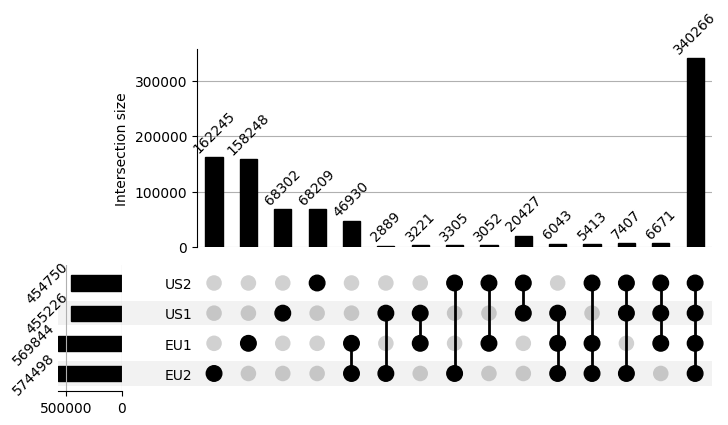

In [20]:
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_contents

# Deine Sets
sets = {
    'EU1': set_simhashes_eu1,
    'EU2': set_simhashes_eu2,
    'US1': set_simhashes_us1,
    'US2': set_simhashes_us2
}

# In UpSet-kompatibles Format umwandeln
data = from_contents(sets)

# Plot erzeugen
fig = plt.figure(figsize=(8, 6))
up = UpSet(data, subset_size='count', show_counts=True)
up.plot(fig=fig)

# Nachträglich alle Textobjekte der Figure anpassen
for ax in fig.axes:
    #for label in ax.get_xticklabels():
    #    label.set_rotation(45)  # Achsen-Beschriftungen
    #for label in ax.get_yticklabels():
    #    label.set_rotation(45)  # falls nötig
    for txt in ax.texts:  # Zahlen im Plot (Balkenbeschriftungen)
        txt.set_rotation(45)

#plt.suptitle("UpSet Plot für 4 Datensätze", fontsize=14)
plt.tight_layout()
plt.savefig('upset_plot.pdf', dpi=300)


In [2]:
import os
import pandas as pd
df = pd.read_csv(os.path.join(os.getcwd(), '..', '..', '..', '02_Data', 'js_hashes', 'simhash_to_profile_export.csv'))
df.head()

,browser_id,simhash_hex
0,openwpm_native_eu_1_omaticall,2bdf0cb7114ef559
1,openwpm_native_eu_1_omaticall,2d1608b75acefd3a
2,openwpm_native_eu_1_omaticall,2d1a3623b1d1dd9a
3,openwpm_native_eu_1_omaticall,2d978af39c5e6179
4,openwpm_native_eu_1_omaticall,33f23427d5d4d0c8


In [3]:
from tqdm import tqdm

tqdm.pandas()

def extract_profile(browser_id):
    if browser_id == 'openwpm_native_eu_1_omaticall':
        return "EU1"
    elif browser_id == 'openwpm_native_eu_2_omaticall':
        return "EU2"
    elif browser_id == 'openwpm_native_us_1_omaticall':
        return "US1"
    elif browser_id == 'openwpm_native_us_2_omaticall':
        return "US2"

df['profile'] = df['browser_id'].progress_apply(extract_profile)
df.head()

100%|██████████| 61510/61510 [00:00<00:00, 2460531.41it/s]


,browser_id,simhash_hex,profile
0,openwpm_native_eu_1_omaticall,2bdf0cb7114ef559,EU1
1,openwpm_native_eu_1_omaticall,2d1608b75acefd3a,EU1
2,openwpm_native_eu_1_omaticall,2d1a3623b1d1dd9a,EU1
3,openwpm_native_eu_1_omaticall,2d978af39c5e6179,EU1
4,openwpm_native_eu_1_omaticall,33f23427d5d4d0c8,EU1


In [6]:
eu1 = df[df['profile'] == 'EU1']
eu2 = df[df['profile'] == 'EU2']
us1 = df[df['profile'] == 'US1']
us2 = df[df['profile'] == 'US2']

distinct_simhashes_eu1 = list(set(eu1['simhash_hex'].tolist()))
distinct_simhashes_eu2 = list(set(eu2['simhash_hex'].tolist()))
distinct_simhashes_us1 = list(set(us1['simhash_hex'].tolist()))
distinct_simhashes_us2 = list(set(us2['simhash_hex'].tolist()))

C:\Users\boett\AppData\Local\Programs\Python\Python311\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
C:\Users\boett\AppData\Local\Programs\Python\Python311\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original objec

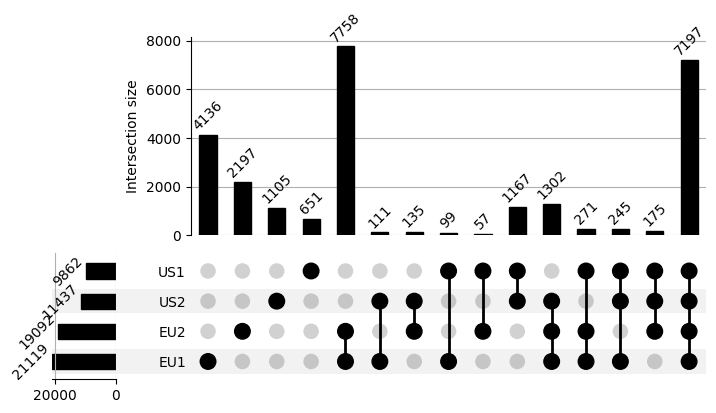

In [9]:
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_contents

sets = {
    'EU1': set(distinct_simhashes_eu1),
    'EU2': set(distinct_simhashes_eu2),
    'US1': set(distinct_simhashes_us1),
    'US2': set(distinct_simhashes_us2)
}

data = from_contents(sets)

fig = plt.figure(figsize=(8, 6))
up = UpSet(data, subset_size='count', show_counts=True)
up.plot(fig=fig)

for ax in fig.axes:
    for txt in ax.texts:
        txt.set_rotation(45)

#plt.suptitle("UpSet Plot für 4 Datensätze", fontsize=14)
plt.tight_layout()
plt.savefig('upset_plot_tracking_scripts.pdf', dpi=300)

In [13]:
for profile, set in sets.items():
    for _profile, _set in sets.items():
        if profile != _profile:
            print(f"Intersection of {profile} - {_profile}: {len(set.intersection(_set))}")
            print(f"Difference of {profile} - {_profile}: {len(set.difference(_set))}")
            print(f"Difference of {_profile} - {profile}: {len(_set.difference(set))}")
        print("---------------")

---------------
Intersection of EU1 - EU2: 16528
Difference of EU1 - EU2: 4591
Difference of EU2 - EU1: 2564
---------------
Intersection of EU1 - US1: 7812
Difference of EU1 - US1: 13307
Difference of US1 - EU1: 2050
---------------
Intersection of EU1 - US2: 8855
Difference of EU1 - US2: 12264
Difference of US2 - EU1: 2582
---------------
Intersection of EU2 - EU1: 16528
Difference of EU2 - EU1: 2564
Difference of EU1 - EU2: 4591
---------------
---------------
Intersection of EU2 - US1: 7700
Difference of EU2 - US1: 11392
Difference of US1 - EU2: 2162
---------------
Intersection of EU2 - US2: 8809
Difference of EU2 - US2: 10283
Difference of US2 - EU2: 2628
---------------
Intersection of US1 - EU1: 7812
Difference of US1 - EU1: 2050
Difference of EU1 - US1: 13307
---------------
Intersection of US1 - EU2: 7700
Difference of US1 - EU2: 2162
Difference of EU2 - US1: 11392
---------------
---------------
Intersection of US1 - US2: 8784
Difference of US1 - US2: 1078
Difference of US2 

In [3]:
s = ""
for i in range(1,68):
    s += f"bar.simhash_hex = foo.cluster_{i} OR "
s

'bar.simhash_hex = foo.cluster_1 OR bar.simhash_hex = foo.cluster_2 OR bar.simhash_hex = foo.cluster_3 OR bar.simhash_hex = foo.cluster_4 OR bar.simhash_hex = foo.cluster_5 OR bar.simhash_hex = foo.cluster_6 OR bar.simhash_hex = foo.cluster_7 OR bar.simhash_hex = foo.cluster_8 OR bar.simhash_hex = foo.cluster_9 OR bar.simhash_hex = foo.cluster_10 OR bar.simhash_hex = foo.cluster_11 OR bar.simhash_hex = foo.cluster_12 OR bar.simhash_hex = foo.cluster_13 OR bar.simhash_hex = foo.cluster_14 OR bar.simhash_hex = foo.cluster_15 OR bar.simhash_hex = foo.cluster_16 OR bar.simhash_hex = foo.cluster_17 OR bar.simhash_hex = foo.cluster_18 OR bar.simhash_hex = foo.cluster_19 OR bar.simhash_hex = foo.cluster_20 OR bar.simhash_hex = foo.cluster_21 OR bar.simhash_hex = foo.cluster_22 OR bar.simhash_hex = foo.cluster_23 OR bar.simhash_hex = foo.cluster_24 OR bar.simhash_hex = foo.cluster_25 OR bar.simhash_hex = foo.cluster_26 OR bar.simhash_hex = foo.cluster_27 OR bar.simhash_hex = foo.cluster_28 OR 